In [3]:
from debiased_spatial_whittle.models.univariate import SquaredExponentialModel, NuggetModel
from debiased_spatial_whittle.grids.base import RectangularGrid
from debiased_spatial_whittle.sampling.simulation import SamplerOnRectangularGrid
from debiased_spatial_whittle.inference.likelihood import DebiasedWhittle, Estimator
from debiased_spatial_whittle.inference.periodogram import Periodogram, ExpectedPeriodogram

In [4]:
import numpy as np

sizes = [64, 128, 256]
n_samples = 1000
pct_obs = 0.5

model = NuggetModel(SquaredExponentialModel(rho=8), nugget=0.01)

results = np.zeros((n_samples, len(sizes)))

In [5]:
for i_size, size in enumerate(sizes):
    grid = RectangularGrid((size, size))
    grid.mask = np.random.rand(size, size) < pct_obs

    sampler = SamplerOnRectangularGrid(model, grid)
    periodogram = Periodogram()
    expected_periodogram = ExpectedPeriodogram(grid, periodogram)
    dbw = DebiasedWhittle(periodogram, expected_periodogram)
    estimator = Estimator(dbw)
    for i_sample in range(n_samples):
        base_model = SquaredExponentialModel(rho=1.)
        base_model.set_param_bounds(dict(rho=(0.1, 100)))
        est_model = NuggetModel(base_model, nugget=0.05)
        est_model.set_param_bounds(dict(nugget=(1e-6, 1e-1)))
        s = sampler()
        estimator(est_model, s)
        print(est_model.children[0].rho)
        results[i_sample, i_size] = est_model.children[0].rho

AttributeError: 'SquaredExponentialModel' object has no attribute 'set_param_bounds'

In [19]:
np.sqrt(np.mean((results - 8) ** 2, axis=0))

array([1.40768377, 0.39625055, 0.15683991])

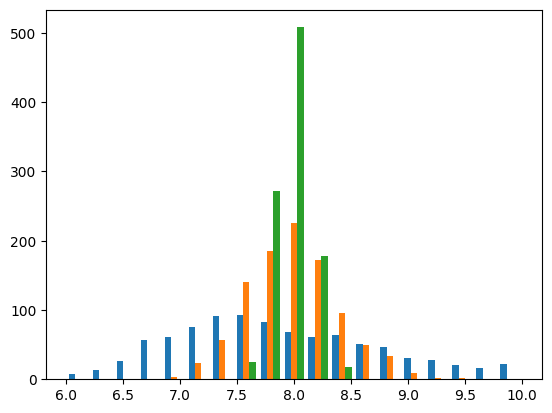

In [22]:
import matplotlib.pyplot as plt
plt.figure()
_ = plt.hist(results, bins=np.linspace(6, 10, 20))